# PART A

In [112]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
with open('emotion-sample.tsv', mode="rt", encoding='utf-8') as f:
  dataset = f.read()

dataset = dataset.split("\n")

dataset = list(map(lambda x: x.split("\t"), dataset)) 

#Dataset is list of lists that contain (text, label) pairs

In [ ]:
#Don't run this if you don't want to annotate the data again

texts = [data[0] for data in dataset]
labels = [data[1] for data in dataset]
emotions = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}

annotated = []

print(emotions)
'''
for text in texts:
  annotation = input(text)
  annotated.append(annotation)
'''

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


Cohen's Kappa score: 0.23566878980891726


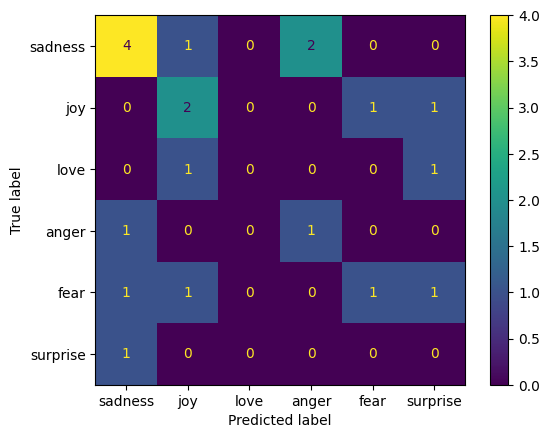

In [ ]:
keys = list(map(str, emotions.keys()))

kappa = cohen_kappa_score(labels, annotated, labels=keys)
print(f"Cohen's Kappa score: {kappa}")

emotion_str = list(emotions.values())
cm = confusion_matrix(labels, annotated, labels=keys)
print(cm.)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_str)
disp.plot()

# Part B

In [122]:
from datasets import Dataset, DatasetDict, concatenate_datasets

In [119]:
with open("imdb-positives.txt", mode="rt", encoding="utf-8") as f:
  positives = f.read().strip().split("\n")

labels = []

for row in positives:
  labels.append("positive")

pos_ds = Dataset.from_dict({"text": positives, "label": labels})

split_1 = pos_ds.train_test_split(test_size=0.2)
split_2 = split_1["test"].train_test_split(test_size=0.5)

pos_dict = DatasetDict({
  'train': split_1["train"],
  'validation': split_2["train"],
  'test': split_2["test"],
})


In [120]:
with open("imdb-negatives.txt", mode="rt", encoding="utf-8") as f:
  negatives = f.read().strip().split("\n")

labels = []

for row in negatives:
  labels.append("negative")

neg_ds = Dataset.from_dict({"text": negatives, "label": labels})

split_1 = neg_ds.train_test_split(test_size=0.2)
split_2 = split_1["test"].train_test_split(test_size=0.5)

neg_dict = DatasetDict({
  'train': split_1["train"],
  'validation': split_2["train"],
  'test': split_2["test"],
})

In [ ]:
train = concatenate_datasets([
  pos_dict["train"],
  neg_dict["train"],
])

validation = concatenate_datasets([
  pos_dict["validation"],
  neg_dict["validation"],
])

test = concatenate_datasets([
  pos_dict["test"],
  neg_dict["test"],
])

#For a more even distribution of positive and negative rows, the combined datasets are shuffled
reviews = DatasetDict({
  'train': train.shuffle(),
  'validation': validation.shuffle(),
  'test': test.shuffle(),  
})

In [130]:
print(reviews)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 40000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 5000
    })
})
